# Jaguar Re-ID — CNN Improved v3

**Architecture** : 5x(Conv2D + BatchNorm + MaxPool2D) → GlobalAveragePooling2D → Dropout(0.5) → Dense(128) → Dense(31)  
**Improvement over Baseline** : +BatchNorm, 5 blocs (32→64→128→256→512), Dropout(0.5), augmentation heavy  
**Diff vs v2** : +5e bloc conv (512), Dropout 0.3→0.5, augmentation moderate→heavy

## 1. Setup & data loading

In [2]:
import sys, os, glob
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# GPU setup — LD_LIBRARY_PATH must be set before TF loads CUDA
nvidia_libs = glob.glob(os.path.join(sys.prefix, 'lib/python*/site-packages/nvidia/*/lib'))
if nvidia_libs:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_libs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Memory growth — avoid grabbing all VRAM at once (other processes may be running)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if not gpus:
    print("WARNING: No GPU detected, training will be slow on CPU!")
    print("Run this in terminal first: export LD_LIBRARY_PATH=$(python3 -c \"import glob; print(':'.join(glob.glob('env/lib/python*/site-packages/nvidia/*/lib')))\")")
    print("Then restart the Jupyter kernel.")

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
MODEL_NAME   = 'cnn_improved_v3'
AUGMENTATION = 'heavy'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [4]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

I0000 00:00:1775825064.398099   70810 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 26501 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:86:00.0, compute capability: 8.6


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [5]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(512, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "cnn_improved_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,642,207 (6.26 MB)

 Trainable params: 1,640,223 (6.26 MB)

 Non-trainable params: 1,984 (7.75 KB)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [6]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [7]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (cnn_improved_v3) ===


I0000 00:00:1775825075.840897   71061 service.cc:153] XLA service 0x7fc6a4040900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775825075.840958   71061 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A6000, Compute Capability 8.6 (Driver: 12.6.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775825075.990171   71061 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775825076.816772   71061 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775825077.072547   71061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5508__.88
I0000 00:00:1775825084.620294   71061 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:0

  lr_0.01: val_acc=0.7810 (best epoch=73)


I0000 00:00:1775825478.164429   71061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_73408__.88
I0000 00:00:1775825488.470319   71060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_73408__.88


  lr_0.001: val_acc=0.8786 (best epoch=65)


I0000 00:00:1775825797.357002   71062 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_135284__.88
I0000 00:00:1775825808.181972   71061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_135284__.88


  lr_0.0001: val_acc=0.7995 (best epoch=82)


In [8]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.878628,65
1,lr_0.0001,0.799472,82
2,lr_0.01,0.781003,73



Best: lr_0.001 → val_acc=0.8786


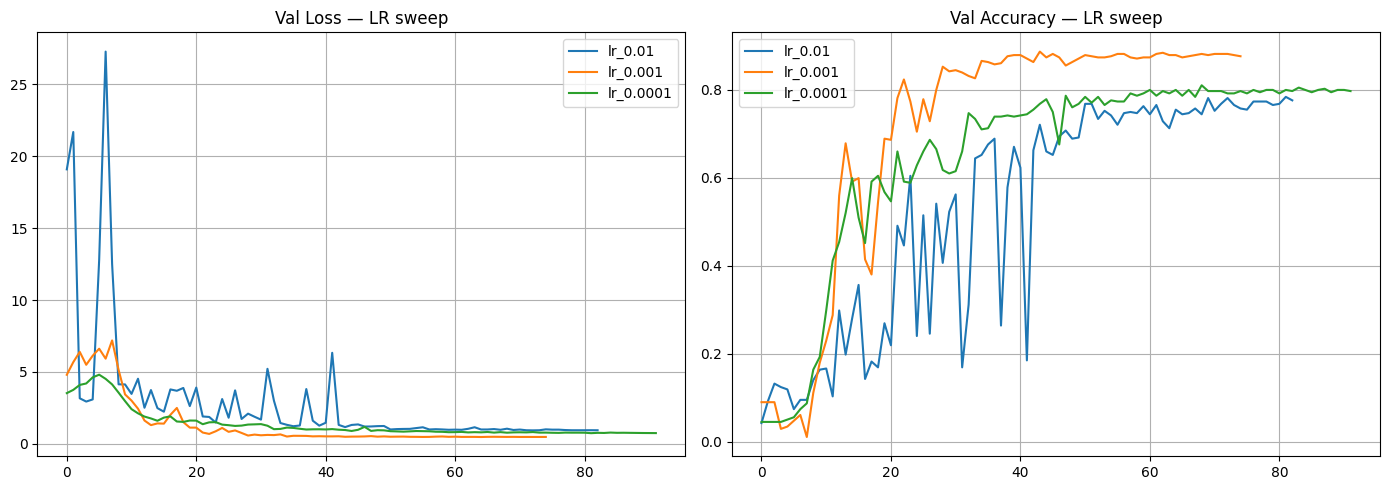

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [10]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1775826190.054296   71061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_210547__.88


47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1207 - loss: 3.4161

I0000 00:00:1775826200.389977   71059 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_210547__.88


48/48 ━━━━━━━━━━━━━━━━━━━━ 26s 301ms/step - accuracy: 0.1504 - loss: 3.1098 - val_accuracy: 0.0897 - val_loss: 4.1525 - learning_rate: 0.0010
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.2480 - loss: 2.6290 - val_accuracy: 0.0871 - val_loss: 5.6379 - learning_rate: 0.0010
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.3179 - loss: 2.3809 - val_accuracy: 0.0396 - val_loss: 6.5341 - learning_rate: 0.0010
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.3443 - loss: 2.2801 - val_accuracy: 0.0079 - val_loss: 6.7980 - learning_rate: 0.0010
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.4156 - loss: 2.0507 - val_accuracy: 0.0053 - val_loss: 6.8190 - learning_rate: 0.0010
Epoch 6/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4406 - loss: 1.9380
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.4433 - loss: 1.9317 - val_accuracy

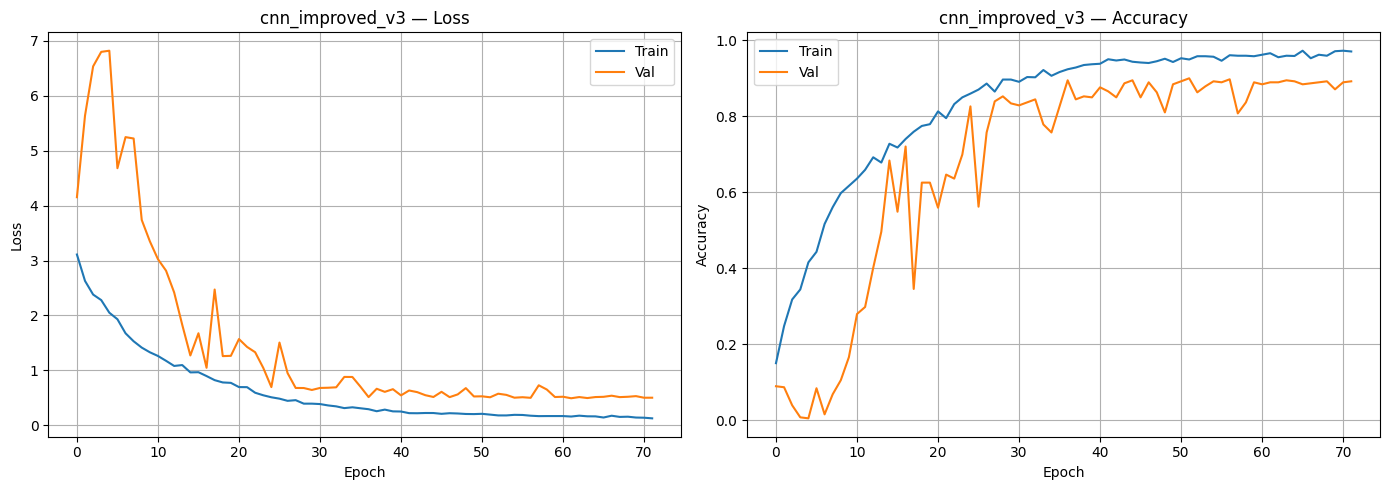

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

cnn_improved_v3 (best LR=0.001):
  Train — Loss: 0.0741, Acc: 0.9868
  Val   — Loss: 0.4934, Acc: 0.8892


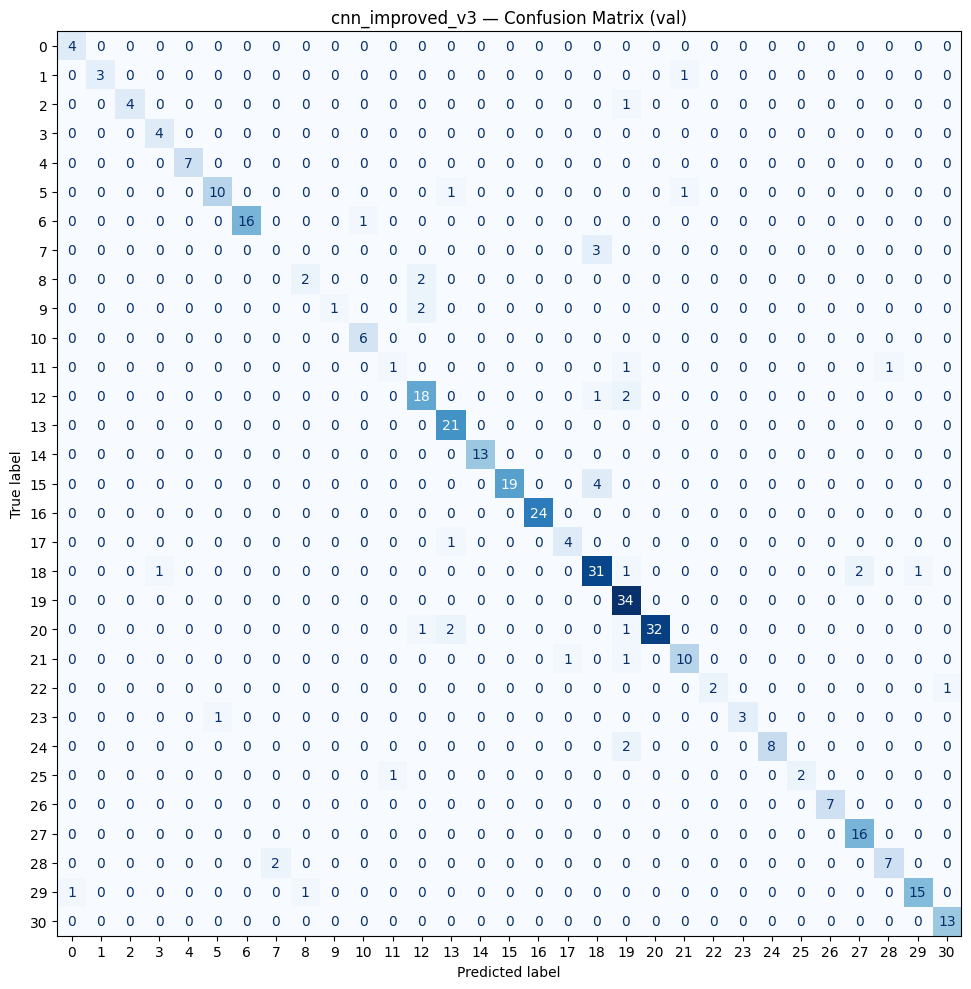

In [13]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [14]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 65 epochs
Epoch 1/65


I0000 00:00:1775826547.669373   71056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_604531__.88


59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1164 - loss: 3.3898

I0000 00:00:1775826558.148898   71062 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_604531__.88


60/60 ━━━━━━━━━━━━━━━━━━━━ 38s 433ms/step - accuracy: 0.1515 - loss: 3.0592
Epoch 2/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.2380 - loss: 2.6398
Epoch 3/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.3203 - loss: 2.3887
Epoch 4/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.3873 - loss: 2.1441
Epoch 5/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.4602 - loss: 1.8964
Epoch 6/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.5082 - loss: 1.7268
Epoch 7/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.5541 - loss: 1.5890
Epoch 8/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.5731 - loss: 1.4702
Epoch 9/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6380 - loss: 1.2967
Epoch 10/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.6449 - loss: 1.2209
Epoch 11/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.6839 - loss: 1.0749
Epoch 12/65
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.7066 -

In [15]:
X_test, test_filenames = load_data('test')

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

del X_test  # free memory

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 346ms/step
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_cnn_improved_v3.csv


,row_id,similarity
0,0,0.852208
1,1,0.662513
2,2,0.633413
3,3,0.673720
4,4,0.723836


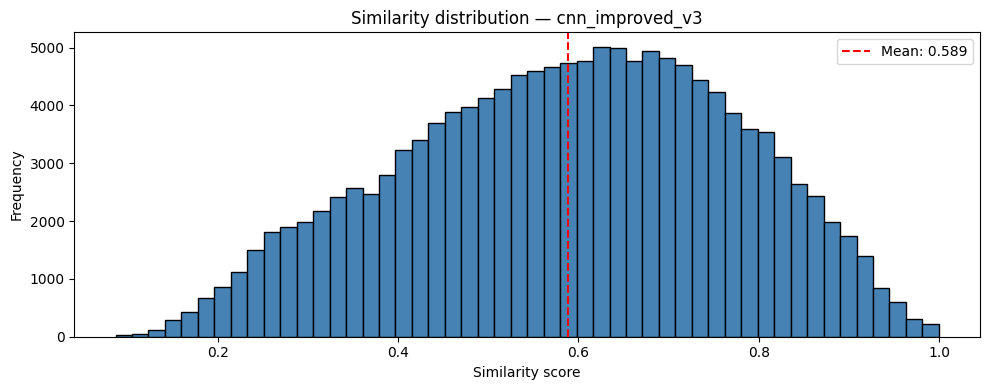

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | 0.9868 | 0.8892 |
| Loss     | 0.0741 | 0.4934 |
| Overfitting ? | — | Modéré (gap ~9.8 pts) |
| Kaggle Score (public) | — | 0.292 |
| Kaggle Score (private) | — | 0.298 |

### Comparaison vs v2

| Métrique | v2 | v3 | Diff |
|----------|----|----|------|
| Sweep best val_acc | 0.9156 | 0.8786 | -3.7 pts |
| Section 4 val_acc | 0.9077 | 0.8892 | -1.9 pts |
| Gap overfitting | 8.6 pts | 9.8 pts | +1.2 pts |
| Final train acc (retrain) | 0.6633 | 0.3113 | -0.35 |
| Kaggle public | 0.361 | 0.292 | -0.069 |
| Kaggle private | 0.343 | 0.298 | -0.045 |

Toutes les métriques sont en baisse. La dégradation la plus révélatrice est le **final train acc à 31%** : le retrain final (sans ReduceLROnPlateau) n'arrive pas à converger — le modèle plus gros + heavy augmentation nécessite beaucoup plus d'epochs avec un LR fixe. Les embeddings soumis à Kaggle viennent donc d'un modèle à peine entraîné.

### Analyse des hyperparamètres — modification par modification

#### 1. Data Augmentation moderate → heavy — le coupable principal

L'augmentation heavy applique **simultanément** rotation (±8°), zoom (±10%), flip, brightness (±0.25) et contrast (±0.25). Avec seulement 1516 images d'entraînement, ces déformations combinées produisent des images trop éloignées des images réelles. Le modèle passe plus de temps à s'adapter aux artefacts de l'augmentation qu'à apprendre les vrais patterns du pelage.

**Preuve** : le sweep perd 3.7 pts de val_acc vs v2 (91.56% → 87.86%). L'augmentation moderate (flip + brightness + contrast, sans rotation ni zoom) produisait des variations réalistes. Le heavy va trop loin — les rotations déforment les contours des rosettes et le zoom perd des portions d'image discriminantes.

**Verdict** : **A reverter.** Revenir à moderate pour v4. L'augmentation moderate a prouvé son efficacité en v2, le heavy est trop agressif pour ce dataset.

#### 2. Dropout 0.3 → 0.5 — bonne idée, masquée par le heavy augmentation

Le Dropout 0.5 désactive la moitié des neurones du vecteur de 512 dimensions (après GAP) à chaque forward pass. En v2, le gap était de 8.6 pts avec Dropout 0.3 — monter à 0.5 devait réduire ce gap.

**Problème** : on ne peut pas isoler l'effet du Dropout 0.5 car il est noyé dans l'effet catastrophique du heavy augmentation. Le gap a augmenté à 9.8 pts, mais c'est probablement le heavy qui empêche le modèle d'apprendre correctement, pas le Dropout.

**Verdict** : **A garder pour v4.** Avec moderate augmentation, le modèle convergera mieux et le Dropout 0.5 pourra jouer son rôle de régularisation sur le vecteur plus large (512 vs 256 en v2). Le train acc en v2 montait à 99.34% avec Dropout 0.3 — le 0.5 devrait freiner cet overfitting sans bloquer l'apprentissage si l'augmentation est raisonnable.

#### 3. 5e bloc conv (512 filtres) — architecture prometteuse, pas en condition de montrer son potentiel

Le 5e bloc ajoute une couche d'abstraction (7×7×512) et produit un embedding plus riche (512-dim avant le Dense(128), vs 256-dim en v2). Le modèle passe de 427K à 1.64M params.

**Problème** : avec heavy aug + dropout 0.5, le modèle n'avait pas assez de capacité effective pour exploiter ces paramètres supplémentaires. Le ratio 1.64M params / 1516 images est élevé (1082 params/image), mais pas rédhibitoire si la régularisation est dosée correctement. En v2, on avait 427K / 1516 = 282 params/image et ça marchait très bien.

**Verdict** : **A garder pour v4.** Le 5e bloc n'a jamais pu montrer son potentiel car le heavy augmentation empêchait la convergence. Avec moderate augmentation, le modèle devrait converger correctement et l'embedding plus riche (512 → 128) pourrait capturer plus de features discriminantes pour la re-ID. À surveiller : si le gap d'overfitting explose (>12 pts), le modèle est trop gros et il faudra revenir à 4 blocs.

#### 4. Final train acc = 31% — symptôme, pas cause

Le retrain final utilise un LR fixe de 0.001 pendant 65 epochs, sans ReduceLROnPlateau. En v2 le résultat était déjà médiocre (66%), en v3 c'est catastrophique (31%). Le modèle plus gros + heavy aug a besoin de plus d'epochs et d'un scheduler de LR pour converger. Ce n'est pas un problème de l'architecture mais du pipeline de retrain.

### Verdict

- [x] Improvable → Instructions pour v4
- [ ] Not Improvable → Plafond atteint
- [ ] Dead-end → On abandonne cette architecture

**Justification** : Les résultats de v3 ne sont pas un échec de l'architecture mais un échec de la régularisation excessive. Le heavy augmentation a empêché le modèle de converger et a masqué l'effet des deux autres modifications (Dropout 0.5 et 5e bloc conv). En revenant à moderate, on pourra enfin évaluer si le 5e bloc et le Dropout 0.5 apportent un gain réel.

**Instructions pour v4** :
- **Revenir à `augmentation='moderate'`** : le heavy est trop agressif pour 1516 images, le moderate a fait ses preuves en v2 (Kaggle 0.361)
- **Garder Dropout(0.5)** : on veut isoler son effet avec moderate aug — si le gap baisse vs v2 (8.6 pts), c'est validé
- **Garder le 5e bloc conv (512)** : l'embedding plus riche (512→128) pourrait améliorer la re-ID si le modèle converge correctement
- En résumé : v4 = architecture de v3 + augmentation de v2

### Interprétation

_Ce notebook illustre un piège classique : changer trop de variables en même temps. En modifiant simultanément l'augmentation, le Dropout et l'architecture, on ne peut pas isoler la cause de la dégradation. L'analyse pointe clairement le heavy augmentation comme coupable principal (la seule modification qui détruit la convergence), mais le Dropout 0.5 et le 5e bloc conv n'ont jamais pu être évalués dans des conditions favorables. La v4 corrige cette erreur méthodologique en ne changeant qu'une variable par rapport à v3 (moderate au lieu de heavy), ce qui permettra d'évaluer le vrai apport de l'architecture 5 blocs + Dropout 0.5._